**Speech Processing and Classification**

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinayshanbhag/bird-song-data-set")

print("Path to dataset files:", path)

100%|██████████| 2.09G/2.09G [00:33<00:00, 66.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vinayshanbhag/bird-song-data-set/versions/1


In [2]:
def load_and_visualize_speech(audio_path):
    # Load audio file
    y, sr = librosa.load(audio_path)

    # Compute spectrogram
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Plot spectrogram
    plt.figure(figsize=(12, 8))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Speech Spectrogram')
    plt.tight_layout()
    plt.show()

In [5]:
import pandas as pd
import os

dataset = pd.read_csv(os.path.join(path, "bird_songs_metadata.csv"))
dataset.head()

,id,genus,species,subspecies,name,recordist,country,location,latitude,longitude,altitude,sound_type,source_url,license,time,date,remarks,filename
0,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-0.wav
1,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-1.wav
2,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-4.wav
3,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-5.wav
4,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-6.wav


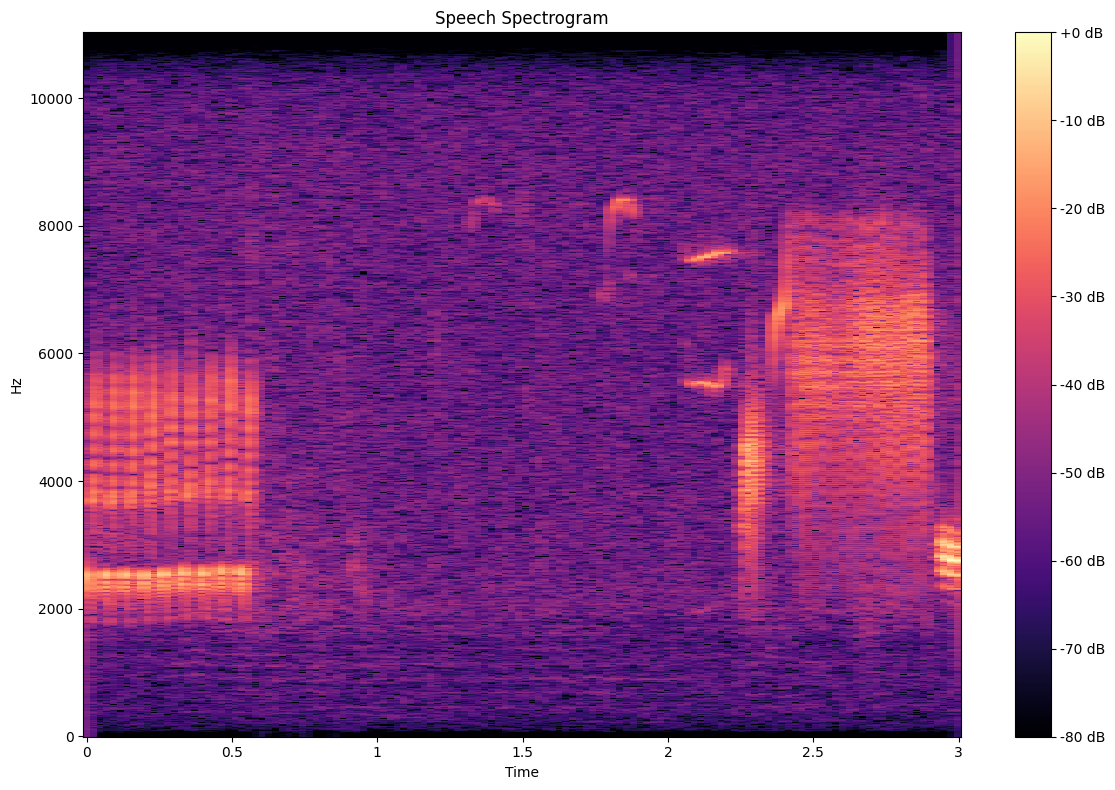

In [9]:
import random

audio_id = random.randint(0, 9106)
load_and_visualize_speech(os.path.join(path, "wavfiles", dataset.loc[audio_id, "filename"]))

In [19]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

class BirdSoundClassifier:
    def __init__(self, num_classes, base_path):
        self.base_path = base_path
        self.model = self.create_model(num_classes)
        self.label_encoder = LabelEncoder()

    def extract_features(self, filename):
        # Construct full file path
        full_path = os.path.join(self.base_path, filename)

        # Extract MFCCs from audio file
        audio_data, _ = librosa.load(full_path)
        mfccs = librosa.feature.mfcc(
            y=audio_data,
            n_mfcc=13,
            hop_length=512,
            n_fft=2048
        )
        return np.mean(mfccs.T, axis=0)

    def create_model(self, num_classes):
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu', input_shape=(13,)),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def prepare_dataset(self, dataframe):
        # Extract features for each filename
        features = [
            self.extract_features(filename)
            for filename in dataframe['filename']
        ]

        # Encode labels
        encoded_labels = self.label_encoder.fit_transform(
            dataframe['species']
        )

        # Split dataset
        X_train, X_test, y_train, y_test = train_test_split(
            features, encoded_labels, test_size=0.2, random_state=42
        )

        return (
            np.array(X_train),
            tf.keras.utils.to_categorical(y_train),
            np.array(X_test),
            tf.keras.utils.to_categorical(y_test)
        )

    def train(self, X_train, y_train, epochs=50):
        return self.model.fit(
            X_train, y_train,
            epochs=epochs,
            validation_split=0.2
        )

    def evaluate_model(self, X_test, y_test):
        """
        Comprehensive model evaluation

        Args:
            X_test (np.array): Test features
            y_test (np.array): One-hot encoded test labels

        Returns:
            dict: Detailed evaluation metrics
        """
        # Predictions
        y_pred = self.model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true_classes = np.argmax(y_test, axis=1)

        # Classification Report
        report = classification_report(
            y_true_classes,
            y_pred_classes,
            target_names=self.label_encoder.classes_,
            output_dict=True
        )

        # Confusion Matrix
        cm = confusion_matrix(y_true_classes, y_pred_classes)

        # Precision, Recall, F1, Support for each class
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true_classes, y_pred_classes, average=None
        )

        # Model Performance Visualization
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d',
                    xticklabels=self.label_encoder.classes_,
                    yticklabels=self.label_encoder.classes_)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.show()

        # Aggregate metrics
        metrics = {
            'accuracy': report['accuracy'],
            'macro_precision': report['macro avg']['precision'],
            'macro_recall': report['macro avg']['recall'],
            'macro_f1_score': report['macro avg']['f1-score'],
            'confusion_matrix': cm,
            'per_class_metrics': {
                'class_names': self.label_encoder.classes_,
                'precision': precision.tolist(),
                'recall': recall.tolist(),
                'f1_score': f1.tolist(),
                'support': support.tolist()
            }
        }

        return metrics

    def learning_curves(self, history):
        """
        Plot training and validation metrics

        Args:
            history: Model training history
        """
        plt.figure(figsize=(12, 4))

        # Accuracy subplot
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        # Loss subplot
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()

In [11]:
num_bird_classes = dataset["species"].nunique()
num_bird_classes

5

In [25]:
classifier = BirdSoundClassifier(num_bird_classes, base_path= os.path.join(path, "wavfiles"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
X_train, y_train, X_test, y_test = classifier.prepare_dataset(dataset)

In [30]:
history = classifier.train(X_train, y_train)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7575 - loss: 0.5958 - val_accuracy: 0.7938 - val_loss: 0.5745
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7598 - loss: 0.5576 - val_accuracy: 0.7823 - val_loss: 0.5904
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7685 - loss: 0.5733 - val_accuracy: 0.7753 - val_loss: 0.5768
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7741 - loss: 0.5590 - val_accuracy: 0.7961 - val_loss: 0.5593
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7846 - loss: 0.5385 - val_accuracy: 0.8007 - val_loss: 0.5741
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7839 - loss: 0.5376 - val_accuracy: 0.7961 - val_loss: 0.5601
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7736 - loss: 0.5471 - val_accuracy: 0.7961 - val_loss: 0.5494
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7906 - loss: 0.5056 - val_accuracy: 0.

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


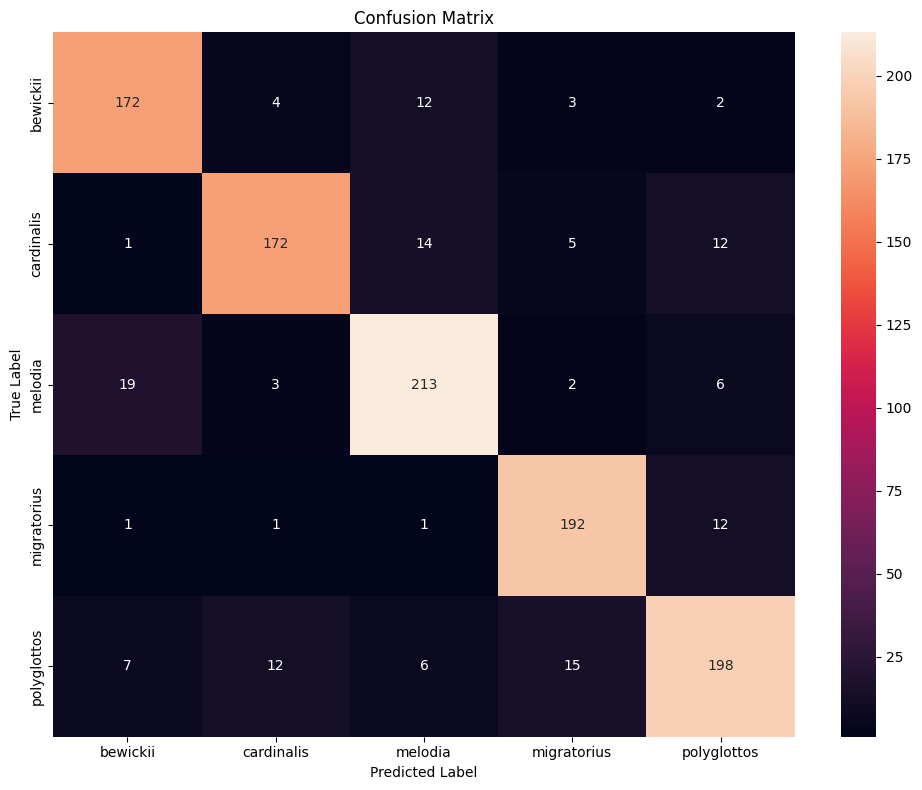

In [31]:
metrics = classifier.evaluate_model(X_test, y_test)

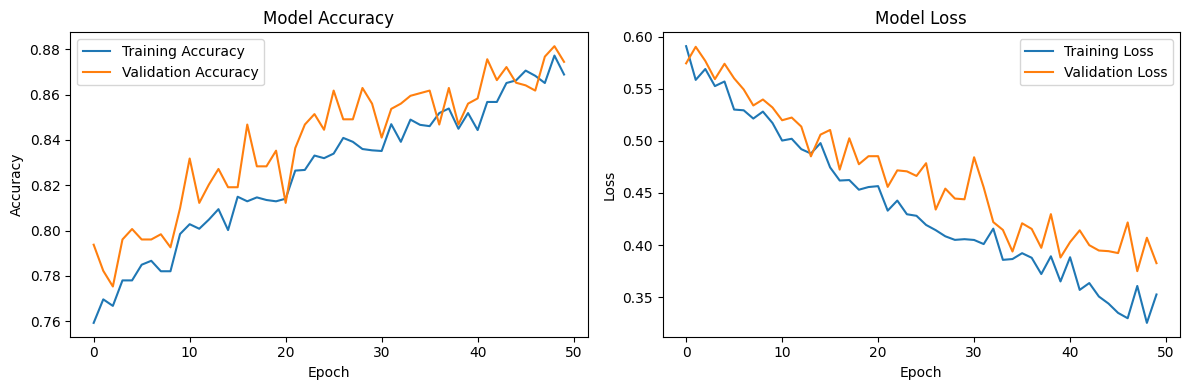

In [32]:
classifier.learning_curves(history)